**Dechection, modele Deep-Learning:**

Ici, on essaie de creer un modele qui prend des images contenant un ou plusieurs dechets juste pour certaines supercategories, et essaie de les localiser et classifier.

In [ ]:
# Monter le Google Drive (c'est ici le dataset se trouve)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Importations des bibliotheques necessaires

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

In [ ]:
# Utiliser CUDA si possible pour accelerer la performance

if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print("Processeur disponible:", device, "device name:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Processeur disponible:", device)

Processeur disponible: cpu


In [ ]:
# Importation des donnees

archive_path = "/content/drive/MyDrive/archive"
csv_path = os.path.join(archive_path, "meta_df.csv")
data_path = os.path.join(archive_path, "data")
df = pd.read_csv(csv_path)
df = df[df["supercategory"].isin(["Plastic bag & wrapper", "Carton", "Bottle", "Can", "Cup", "Styrofoam piece", "Paper", "Plastic container", "Lid"])]
print(f"Nombre total d'annotations: {len(df)}")
print(f"\nSupercategories:\n{df['supercategory'].value_counts()}")

Nombre total d'annotations: 2424

Supercategories:
supercategory
Plastic bag & wrapper    850
Bottle                   439
Can                      273
Carton                   251
Cup                      192
Paper                    148
Styrofoam piece          112
Lid                       87
Plastic container         72
Name: count, dtype: int64


In [ ]:
# Encoding des labels (supercategories)

label = "supercategory"
sc = sorted(df[label].unique())
c2i = {c: i for i, c in enumerate(sc)}
i2c = {i: c for c, i in c2i.items()}
nbr_classes = len(sc)
print(f"\nNombre de classes: {nbr_classes} -> {sc}")


Nombre de classes: 9 -> ['Bottle', 'Can', 'Carton', 'Cup', 'Lid', 'Paper', 'Plastic bag & wrapper', 'Plastic container', 'Styrofoam piece']


In [ ]:
# Creer la classe TACODataset (image + label + bbox)

IMG_SIZE = 128

class TACODataset(Dataset):

    def __init__(self, dataframe, data_path, label, c2i, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_path = data_path
        self.label = label
        self.c2i = c2i
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        ligne = self.df.iloc[idx]
        img_path = os.path.join(self.data_path, ligne["img_file"])
        image = Image.open(img_path).convert("RGB")

        orig_w, orig_h = image.size

        lb = self.c2i[ligne[self.label]]

        bx = ligne["x"] / orig_w
        by = ligne["y"] / orig_h
        bw = ligne["width"] / orig_w
        bh = ligne["height"] / orig_h
        bbox = torch.tensor([bx, by, bw, bh], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, lb, bbox

In [ ]:
# Transformation d'images en tenseurs

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# Preparation, repartition et loading des donnees

N = len(df)
N_train = int(N * 0.7)
N_valid = int(N * 0.15)
N_test  = N - N_train - N_valid

df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_train = df_shuffled.iloc[:N_train]
df_valid = df_shuffled.iloc[N_train:N_train+N_valid]
df_test  = df_shuffled.iloc[N_train+N_valid:]

train_dataset = TACODataset(df_train, data_path, label, c2i, train_transform)
valid_dataset = TACODataset(df_valid, data_path, label, c2i, val_test_transform)
test_dataset  = TACODataset(df_test,  data_path, label, c2i, val_test_transform)

batch_size = 32
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
validloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Data:\nTrain: {N_train} - Valid: {N_valid} - Test: {N_test}")

Data:
Train: 1696 - Valid: 363 - Test: 365


In [ ]:
# Classe de l'architecture du modele CNN (detection + localisation)

class CNN(nn.Module):

    def __init__(self, nbr_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        self.dropout = nn.Dropout(p=0.5)
        self.cls_head  = nn.Linear(64 * 16 * 16, nbr_classes)
        self.bbox_head = nn.Linear(64 * 16 * 16, 4)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.dropout(x)
        return self.cls_head(x), self.bbox_head(x)

In [ ]:
# Fonctions des boucles d'entrainement, validation, et evaluation

def train_loop(dataloader, model, loss_cls, loss_bbox, optimizer, device):
    nb_batches = len(dataloader)
    epoch_loss = 0
    pbar = tqdm(total=nb_batches, desc='Training', position=0)
    for X, y, bbox in dataloader:
        X, y, bbox = X.to(device), y.to(device), bbox.to(device)
        pred_cls, pred_bbox = model(X.float())
        loss = loss_cls(pred_cls, y) + loss_bbox(pred_bbox, bbox)
        epoch_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.set_postfix({'train_loss': loss.item()}, refresh=True)
        pbar.update(1)
    pbar.close()
    return epoch_loss / nb_batches

def valid_loop(dataloader, model, loss_cls, loss_bbox, device):
    nb_batches = len(dataloader)
    valid_loss = 0
    pbar = tqdm(total=nb_batches, desc='Validation', position=0)
    with torch.no_grad():
        for X, y, bbox in dataloader:
            X, y, bbox = X.to(device), y.to(device), bbox.to(device)
            pred_cls, pred_bbox = model(X.float())
            loss = loss_cls(pred_cls, y) + loss_bbox(pred_bbox, bbox)
            valid_loss += loss.item()
            pbar.set_postfix({'valid_loss': valid_loss}, refresh=True)
            pbar.update(1)
    pbar.close()
    return valid_loss / nb_batches

def accuracy_loop(dataloader, model, device):
    Total = len(dataloader.dataset)
    Positifs = 0
    with torch.no_grad():
        for X, y, bbox in dataloader:
            X, y = X.to(device), y.to(device)
            pred_cls, _ = model(X.float())
            y_pred = torch.argmax(pred_cls, dim=1)
            Positifs += torch.sum(y_pred == y)
    return (Positifs.cpu().numpy() / Total) * 100

def perf_loop(dataloader, model, device):
    Total = len(dataloader.dataset)
    Positifs = 0
    with torch.no_grad():
        for X, y, bbox in dataloader:
            X, y = X.to(device), y.to(device)
            pred_cls, _ = model(X.float())
            prob_pred = nn.Softmax(dim=1)(pred_cls)
            y_pred = torch.argmax(prob_pred, dim=1)
            Positifs += torch.sum(y_pred == y)
    return Positifs.cpu().numpy(), Total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Validation: 100%|██████████| 12/12 [00:55<00:00,  4.64s/it, valid_loss=37.4]


Epoch 1: best validation loss: 3.1172 | train_acc: 27.59% | valid_acc: 27.00%


  7%|▋         | 2/30 [18:39<4:14:27, 545.27s/it]

Epoch 2: best validation loss: 2.5065 | train_acc: 33.84% | valid_acc: 32.51%


 13%|█▎        | 4/30 [34:45<3:38:36, 504.49s/it]

...

Epoch 21: best validation loss: 2.0362 | train_acc: 45.52% | valid_acc: 38.57%


 83%|████████▎ | 25/30 [3:23:51<40:13, 482.79s/it]

Epoch 25: best validation loss: 1.9985 | train_acc: 47.52% | valid_acc: 38.84%


100%|██████████| 30/30 [4:04:39<00:00, 489.30s/it]


Training done!


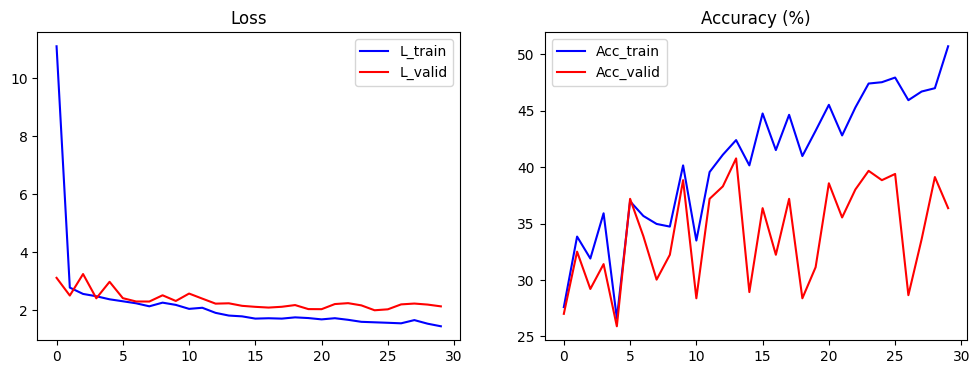

In [ ]:
# Entrainement du modele CNN

torch.manual_seed(42)

epochs = 30
learning_rate = 1e-3
OPTIM = "ADAM"
Model_name = "/content/drive/MyDrive/best_TACO_CNN_detection.pt"

writer = SummaryWriter()

my_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_loss_cls  = nn.CrossEntropyLoss()
my_loss_bbox = nn.MSELoss()

if OPTIM == "ADAM":
    my_optimizer = torch.optim.Adam(my_CNN.parameters(), lr=learning_rate)
    my_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(my_optimizer, patience=3, factor=0.5)
else:
    my_optimizer = torch.optim.SGD(my_CNN.parameters(), lr=learning_rate)
    my_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(my_optimizer, patience=3, factor=0.5)

train_loss = []
valid_loss = []
train_acc = []
valid_acc = []
best_valid_loss = float('inf')
best_iter = 0

for t in tqdm(range(epochs)):
    train_epoch_loss = train_loop(trainloader, my_CNN, my_loss_cls, my_loss_bbox, my_optimizer, device)
    train_loss.append(train_epoch_loss)
    writer.add_scalar('Loss/train', train_epoch_loss, t)

    valid_epoch_loss = valid_loop(validloader, my_CNN, my_loss_cls, my_loss_bbox, device)
    valid_loss.append(valid_epoch_loss)
    writer.add_scalar('Loss/valid', valid_epoch_loss, t)
    my_scheduler.step(valid_epoch_loss)

    t_acc = accuracy_loop(trainloader, my_CNN, device)
    v_acc = accuracy_loop(validloader, my_CNN, device)
    train_acc.append(t_acc)
    valid_acc.append(v_acc)
    writer.add_scalar('Accuracy/train', t_acc, t)
    writer.add_scalar('Accuracy/valid', v_acc, t)

    if valid_epoch_loss < best_valid_loss:
        best_valid_loss = valid_epoch_loss
        best_iter = t
        print(f"Epoch {t+1}: best validation loss: {best_valid_loss:.4f} | train_acc: {t_acc:.2f}% | valid_acc: {v_acc:.2f}%")
        torch.save(my_CNN.state_dict(), Model_name)

print('Training done!')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_loss, "b", label="L_train")
ax1.plot(valid_loss, "r", label="L_valid")
ax1.legend()
ax1.set_title("Loss")
ax2.plot(train_acc, "b", label="Acc_train")
ax2.plot(valid_acc, "r", label="Acc_valid")
ax2.legend()
ax2.set_title("Accuracy (%)")
plt.show()

In [ ]:
# Test du modele

from sklearn.metrics import classification_report

my_best_CNN = CNN(nbr_classes=nbr_classes).to(device)
my_best_CNN.load_state_dict(torch.load(Model_name))

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y, bbox in testloader:
        X = X.to(device)
        pred_cls, _ = my_best_CNN(X.float())
        y_pred = torch.argmax(pred_cls, dim=1)
        all_preds.extend(y_pred.cpu().numpy())
        all_labels.extend(y.numpy())

Positifs = sum(p==l for p,l in zip(all_preds, all_labels))
Total = len(all_labels)
print(f"Test accuracy: {Positifs}/{Total} = {Positifs/Total*100:.2f}%")
print(f"Best epoch: {best_iter+1}")
print(f"Trainable parameters: {count_parameters(my_best_CNN)}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=sc))

writer.add_hparams({'lr': learning_rate, 'bsize': batch_size},
                   {'hparam/accuracy': Positifs/Total, 'hparam/loss': best_valid_loss})
writer.close()

Test accuracy: 125/365 = 34.25%
Best epoch: 25
Trainable parameters: 236813

Classification Report:
                       precision    recall  f1-score   support

               Bottle       0.36      0.36      0.36        69
                  Can       0.23      0.23      0.23        35
               Carton       0.34      0.25      0.29        44
                  Cup       0.19      0.14      0.16        28
                  Lid       0.25      0.08      0.12        12
                Paper       0.18      0.11      0.14        18
Plastic bag & wrapper       0.42      0.59      0.49       123
    Plastic container       0.00      0.00      0.00        14
      Styrofoam piece       0.11      0.05      0.06        22

             accuracy                           0.34       365
            macro avg       0.23      0.20      0.21       365
         weighted avg       0.31      0.34      0.32       365

